#### **Problem**

A telecom company rolls out a Loyalty Program aimed at reducing customer churn. The program is not randomly assigned — it targets customers based on a composite loyalty score that depends on their tenure, spending, and complaint history.

**Goal:** We want to know the loyalty program caused reduction in churn or not?

**The challenge:** Customers who received the program are systematically different from those who didn't. Naive comparison would be biased.

#### **Load Data**

| Variable | Type | Role |
|----------|------|------|
| `tenure_months` | Continuous | Confounder |
| `monthly_spend` | Continuous | Confounder |
| `num_complaints` | Count | Confounder |
| `loyalty_score` | Continuous (0–100) | Running variable (RDD) |
| `treatment` | Binary (0/1) | Did they get the loyalty program? |
| `post` | Binary (0/1) | Pre-period (0) or post-period (1) |
| `churned` | Binary (0/1) | Did they leave? (our outcome) |

For example:
- `treatment` = 0 -> user is in control group and did not get program
- `pre` & `Churn` = 1 -> Before program, user churned
- `post` & `Churn` = 1 -> After program, user have already churned

<hr>

- `treatment` = 1 -> user is in treatment group and did get program
- `pre` & `Churn` = 0 -> Before program, user did not churn
- `post` & `Churn` = 1 -> After program, user churned

In [21]:
import pandas as pd
df = pd.read_csv('telecom_churn.csv')
df.head()

,customer_id,period,post,treatment,tenure_months,monthly_spend,num_complaints,loyalty_score,churned
0,0,post,1,0,42,61.18,2,48.29,1
1,0,pre,0,0,42,61.18,2,48.29,1
2,1,post,1,0,29,77.37,2,48.10,0
3,1,pre,0,0,29,77.37,2,48.10,0
4,2,post,1,0,27,49.09,0,47.00,0


#### **Why we need DiD and Casual Inference?**

In [22]:
# Basic descriptive statistics
print('=== POST-PERIOD SUMMARY ===')
df_post = df[df['post'] == 1]

print(f'\nTotal customers: {len(df_post):,}')
print(f'Treatment rate:  {df_post["treatment"].mean():.1%}')
print(f'\nChurn rates by group:')
print(df_post.groupby('treatment')['churned'].agg(['mean', 'count'])
      .rename(index={0: 'Control (no program)', 1: 'Treated (program)'}))

print(f'\nNaive difference: {df_post[df_post.treatment==1]["churned"].mean() - df_post[df_post.treatment==0]["churned"].mean():.4f}')

=== POST-PERIOD SUMMARY ===

Total customers: 5,000
Treatment rate:  36.3%

Churn rates by group:
                          mean  count
treatment                            
Control (no program)  0.398430   3185
Treated (program)     0.284848   1815

Naive difference: -0.1136


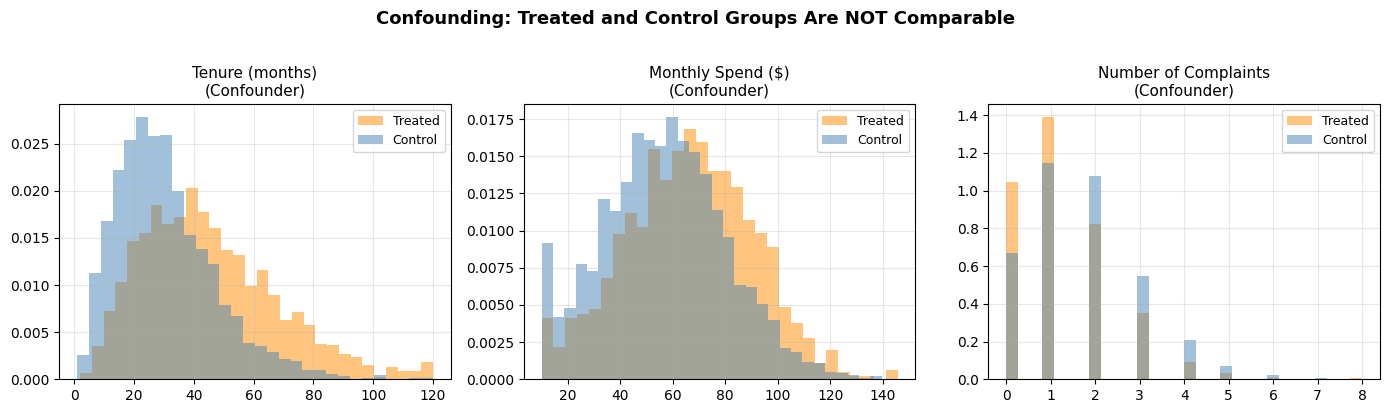


Notice how treated customers have higher tenure and spend!
This is WHY we need causal methods — simple comparison is misleading.


In [23]:
# Visualize the confounding problem
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

confounders = ['tenure_months', 'monthly_spend', 'num_complaints']
titles = ['Tenure (months)', 'Monthly Spend ($)', 'Number of Complaints']

for ax, var, title in zip(axes, confounders, titles):
    for treat_val, label, color in [(1, 'Treated', 'darkorange'), (0, 'Control', 'steelblue')]:
        subset = df_post[df_post['treatment'] == treat_val][var]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(f'{title}\n(Confounder)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Confounding: Treated and Control Groups Are NOT Comparable',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\nNotice how treated customers have higher tenure and spend!')
print('This is WHY we need causal methods — simple comparison is misleading.')

#### **DiD Analysis**

The DiD estimator compares the *change* in churn across time between treated and control groups:

$$\hat{\tau}_{DiD} = (\bar{Y}_{treated,post} - \bar{Y}_{treated,pre}) - (\bar{Y}_{control,post} - \bar{Y}_{control,pre})$$

Three specifications we'll run (from simple → rigorous):
1. **Manual 2×2 table** — raw group means
2. **OLS DiD (LPM)** — regression form with and without controls (`statsmodels`)
3. **Two-Way Fixed Effects (TWFE)** — customer + period FE, the panel-data gold standard (`linearmodels`)

##### **Run 1: Manual 2×2 table (Parallel Trends Check)**

=== 2×2 DiD Table ===
post       Post-period  Pre-period  Δ (Post − Pre)
treatment                                         
Control         0.3984      0.4217         -0.0232
Treated         0.2848      0.3912         -0.1063

Manual DiD estimate (ATT): -0.0831
Interpretation: loyalty program changed churn by -8.31 percentage points


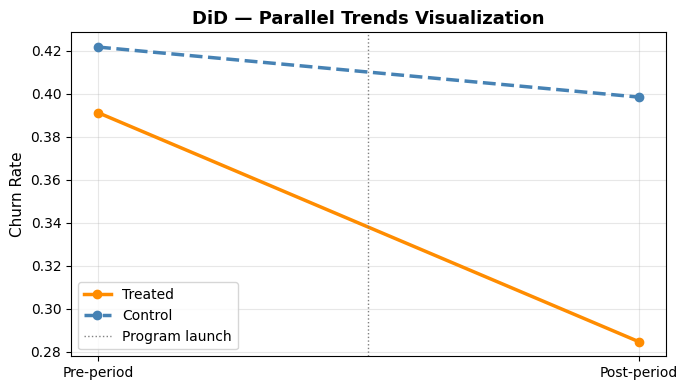

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

# ── 2×2 group means ──────────────────────────────────────────────────────────
means = (
    df.groupby(['treatment', 'post'])['churned']
    .mean()
    .rename(index={0: 'Control', 1: 'Treated'}, level=0)
    .rename(index={0: 'Pre', 1: 'Post'}, level=1)
    .unstack('post')
    .rename(columns={'Pre': 'Pre-period', 'Post': 'Post-period'})
)
means['Δ (Post − Pre)'] = means['Post-period'] - means['Pre-period']
print('=== 2×2 DiD Table ===')
print(means.round(4).to_string())

did_manual = means.loc['Treated', 'Δ (Post − Pre)'] - means.loc['Control', 'Δ (Post − Pre)']
print(f'\nManual DiD estimate (ATT): {did_manual:.4f}')
print(f'Interpretation: loyalty program changed churn by {did_manual*100:.2f} percentage points')


# Plotting the parallel trends--------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
periods = ['Pre-period', 'Post-period']

for group, color, ls in [('Treated', 'darkorange', '-'), ('Control', 'steelblue', '--')]:
    vals = [means.loc[group, 'Pre-period'], means.loc[group, 'Post-period']]
    ax.plot(periods, vals, marker='o', linewidth=2.5, label=group, color=color, linestyle=ls)

ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, label='Program launch')
ax.set_ylabel('Churn Rate', fontsize=11)
ax.set_title('DiD — Parallel Trends Visualization', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### **Run 2: OLS DiD (Linear Probability Model)**

The regression form of DiD:

$$\text{churned}_{it} = \alpha + \beta_1 \cdot \text{post}_t + \beta_2 \cdot \text{treatment}_i + \underbrace{\beta_3 \cdot (\text{post}_t \times \text{treatment}_i)}_{\text{DiD estimate = ATT}} + \varepsilon_{it}$$

`β₃` is the **causal estimate** — the ATT (Average Treatment Effect on the Treated).  
We run it twice: without and with covariates to check robustness.

In [ ]:
# ── Model 1: basic DiD (no controls) ─────────────────────────────────────────
m1 = smf.ols(
    'churned ~ treatment + post + treatment:post',
    data=df
).fit(cov_type='HC3')   # heteroskedasticity-robust SEs — standard in practice


# ── Model 2: DiD + covariates (controls for observed confounding) ─────────────
m2 = smf.ols(
    'churned ~ treatment + post + treatment:post + tenure_months + monthly_spend + num_complaints',
    data=df
).fit(cov_type='HC3')



# set up a summary table for the DiD estimates-------------------------
def summarise(model, label):
    row = model.params[['treatment:post']].to_frame(name='coef')
    row['se']    = model.bse[['treatment:post']]
    row['pval']  = model.pvalues[['treatment:post']]
    row['ci_lo'] = model.conf_int().loc['treatment:post', 0]
    row['ci_hi'] = model.conf_int().loc['treatment:post', 1]
    row['r2']    = model.rsquared
    row.index    = [label]
    return row

results = pd.concat([summarise(m1, 'OLS DiD (no controls)'),
                     summarise(m2, 'OLS DiD + covariates')])

print('=== OLS DiD Results (ATT = treatment:post coefficient) ===')
print(results.round(4).to_string())

print('\n--- Model 1 key output ---')
print(m1.summary().tables[1])

print('\n--- Model 2 key output ---')
print(m2.summary().tables[1])

=== OLS DiD Results (ATT = treatment:post coefficient) ===
                         coef      se  pval   ci_lo   ci_hi      r2
OLS DiD (no controls) -0.0831  0.0199   0.0 -0.1221 -0.0441  0.0098
OLS DiD + covariates  -0.0831  0.0196   0.0 -0.1215 -0.0447  0.0352

--- Model 1 key output ---
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4217      0.009     48.174      0.000       0.405       0.439
treatment         -0.0305      0.014     -2.113      0.035      -0.059      -0.002
post              -0.0232      0.012     -1.885      0.059      -0.047       0.001
treatment:post    -0.0831      0.020     -4.178      0.000      -0.122      -0.044

--- Model 2 key output ---
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        

##### **Run 3: Two-Way Fixed Effects (TWFE) Panel DiD**

The most rigorous specification for panel data. We absorb **all customer-level time-invariant heterogeneity** (entity FE) and **all common time shocks** (time FE):

$$\text{churned}_{it} = \alpha_i + \alpha_t + \underbrace{\beta \cdot (\text{post}_t \times \text{treatment}_i)}_{\text{ATT}} + \varepsilon_{it}$$

This is equivalent to "within-customer" comparison over time, removing the need to control for observed confounders that are stable over time (tenure, loyalty score, etc.).

In [26]:
# ── Prepare panel index: (entity=customer_id, time=post) ─────────────────────
df_panel = df.set_index(['customer_id', 'post'])

# ── TWFE: entity FE + time FE, clustered SEs by customer (standard practice) ─
m3 = PanelOLS(
    dependent=df_panel['churned'],
    exog=df_panel[['treatment']].assign(did=df_panel['treatment'] * df_panel.index.get_level_values('post')),
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

print('=== Two-Way Fixed Effects (TWFE) DiD ===')
print(m3.summary.tables[1])

twfe_att   = m3.params['did']
twfe_se    = m3.std_errors['did']
twfe_pval  = m3.pvalues['did']
twfe_ci    = m3.conf_int().loc['did']          # Series with index ['lower', 'upper']
twfe_ci_lo = twfe_ci['lower']
twfe_ci_hi = twfe_ci['upper']

print(f'\nATT (DiD): {twfe_att:.4f}  SE: {twfe_se:.4f}  p-value: {twfe_pval:.4f}')
print(f'95% CI: [{twfe_ci_lo:.4f}, {twfe_ci_hi:.4f}]')

=== Two-Way Fixed Effects (TWFE) DiD ===
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
did           -0.0831     0.0278    -2.9943     0.0028     -0.1375     -0.0287

ATT (DiD): -0.0831  SE: 0.0278  p-value: 0.0028
95% CI: [-0.1375, -0.0287]


##### **Results Summary & Business Interpretation**

In [27]:
# ── Collect all ATT estimates for comparison ──────────────────────────────────
summary = pd.DataFrame({
    'Model':    ['Manual 2×2',        'OLS DiD',                   'OLS DiD + controls',         'TWFE (panel)'],
    'ATT':      [did_manual,           m1.params['treatment:post'],  m2.params['treatment:post'],   twfe_att],
    'SE':       [np.nan,               m1.bse['treatment:post'],     m2.bse['treatment:post'],      twfe_se],
    'p-value':  [np.nan,               m1.pvalues['treatment:post'], m2.pvalues['treatment:post'],  twfe_pval],
    'CI lower': [np.nan,               m1.conf_int().loc['treatment:post', 0], m2.conf_int().loc['treatment:post', 0], twfe_ci_lo],
    'CI upper': [np.nan,               m1.conf_int().loc['treatment:post', 1], m2.conf_int().loc['treatment:post', 1], twfe_ci_hi],
})
print('=== ATT Comparison Across Specifications ===')
print(summary.set_index('Model').round(4).to_string())

=== ATT Comparison Across Specifications ===
                       ATT      SE  p-value  CI lower  CI upper
Model                                                          
Manual 2×2         -0.0831     NaN      NaN       NaN       NaN
OLS DiD            -0.0831  0.0199   0.0000   -0.1221   -0.0441
OLS DiD + controls -0.0831  0.0196   0.0000   -0.1215   -0.0447
TWFE (panel)       -0.0831  0.0278   0.0028   -0.1375   -0.0287


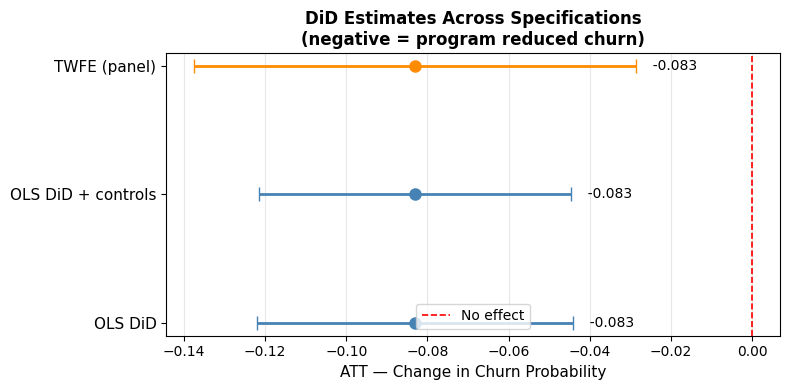


=== Business Conclusion ===
TWFE DiD estimate: -8.31 percentage points
The loyalty program REDUCED churn by 8.31 pp (statistically significant, p=0.0028)

Note: Naive comparison gave -8.31 pp — DiD corrects this for pre-existing differences between groups.


In [28]:
# ── Forest plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
models_plot = summary.dropna(subset=['SE'])
colors = ['steelblue', 'steelblue', 'darkorange']

for i, (_, row) in enumerate(models_plot.iterrows()):
    ax.errorbar(row['ATT'], i,
                xerr=[[row['ATT'] - row['CI lower']], [row['CI upper'] - row['ATT']]],
                fmt='o', color=colors[i], capsize=5, markersize=8, linewidth=2)
    ax.text(row['CI upper'] + 0.002, i, f"  {row['ATT']:.3f}", va='center', fontsize=10)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='No effect')
ax.set_yticks(range(len(models_plot)))
ax.set_yticklabels(models_plot['Model'], fontsize=11)
ax.set_xlabel('ATT — Change in Churn Probability', fontsize=11)
ax.set_title('DiD Estimates Across Specifications\n(negative = program reduced churn)',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ── Business summary ──────────────────────────────────────────────────────────
best = summary.loc[summary['Model'] == 'TWFE (panel)', 'ATT'].values[0]
print(f'\n=== Business Conclusion ===')
print(f'TWFE DiD estimate: {best*100:.2f} percentage points')
sig = 'statistically significant' if twfe_pval < 0.05 else 'NOT statistically significant'
direction = 'REDUCED' if best < 0 else 'INCREASED'
print(f'The loyalty program {direction} churn by {abs(best)*100:.2f} pp ({sig}, p={twfe_pval:.4f})')
print(f'\nNote: Naive comparison gave {(summary.loc[0,"ATT"])*100:.2f} pp — '
      f'DiD corrects this for pre-existing differences between groups.')

#### **PSM Analysis**

PSM creates a "fair comparison" by finding treated and control customers who are **statistically similar** on all observed confounders.

Instead of comparing ALL treated vs ALL control customers, we match each treated customer to their "twin" in the control group.

The **propensity score** $e(X)$ is the probability of being treated given observed covariates:

$$e(X_i) = P(T_i = 1 \mid X_i)$$

**Balancing property**: If two customers have the same propensity score, they are equally likely to be treated — so conditioning on $e(X)$ is like conditioning on all of $X$.

Four steps in standard PSM practice:
1. **Estimate propensity scores** — To find out what is probability of falling in treatment group for each user.
2. **Check overlap (common support)** — treated and control must share the same PS range
3. **Match + check balance** — 1:1 nearest-neighbor with caliper; SMD < 0.1 = good balance
4. **Estimate ATT on matched sample** — simple mean difference + regression for precision

##### **Step 1 — Estimate Propensity Scores**

We use logistic regression to model the probability of receiving the loyalty program as a function of all observed confounders. PSM works on cross-sectional data, so we use the **post-period** snapshot (one row per customer).

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# ── Use post-period: one row per customer ─────────────────────────────────────
df_post = df[df['post'] == 1].copy().reset_index(drop=True)

CONFOUNDERS = ['tenure_months', 'monthly_spend', 'num_complaints', 'loyalty_score']

X = df_post[CONFOUNDERS].values
y = df_post['treatment'].values

In [30]:
# Standardise before logistic regression (improves convergence, common practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

df_post['ps']       = lr.predict_proba(X_scaled)[:, 1]   # P(treated | X)
df_post['logit_ps'] = np.log(df_post['ps'] / (1 - df_post['ps']))  # logit scale for caliper

print('=== Propensity Score Model ===')
print(f'C-statistic (AUC): {lr.score(X_scaled, y):.3f}  '
      f'(>0.5 = PS model has discriminating power)')

print('\nPS summary by group:')
print(df_post.groupby('treatment')['ps']
      .describe()[['mean','std','min','25%','50%','75%','max']]
      .rename(index={0:'Control', 1:'Treated'}).round(3).to_string())

=== Propensity Score Model ===
C-statistic (AUC): 0.793  (>0.5 = PS model has discriminating power)

PS summary by group:
            mean    std   min    25%    50%    75%    max
treatment                                                
Control    0.267  0.182  0.01  0.134  0.233  0.352  0.988
Treated    0.532  0.235  0.01  0.398  0.545  0.700  0.992


The result shows there is really bias in assigning people to treatment and control group

##### **Step 2 — Overlap Check (Common Support)**

Before matching, we must verify that treated and control customers share a common PS range. If they don't overlap, PSM cannot work — there are no valid counterfactuals.

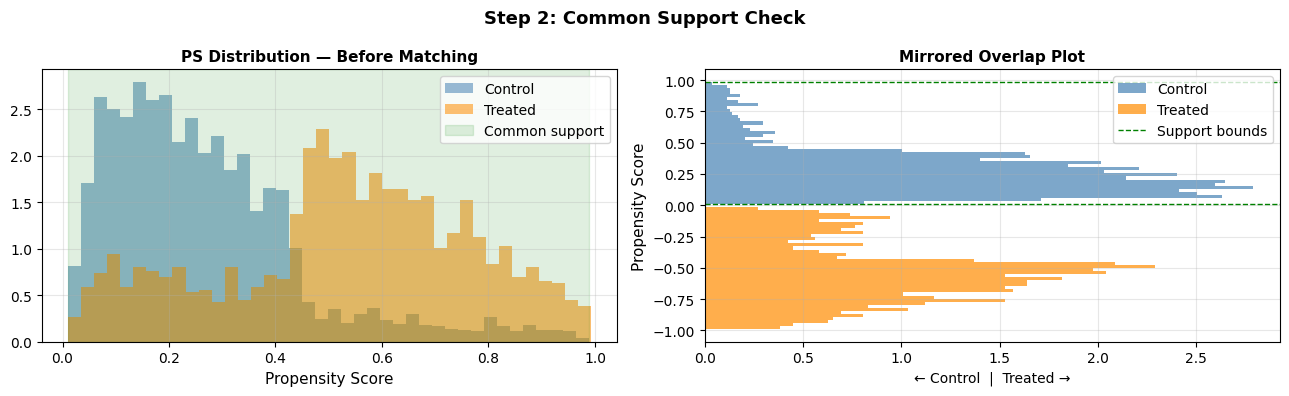

Common support region: [0.010, 0.988]
Treated customers in common support: 99.8%
✓ Overlap looks good — PSM matching can proceed.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

treated_ps = df_post.loc[df_post['treatment'] == 1, 'ps']
control_ps = df_post.loc[df_post['treatment'] == 0, 'ps']

# ── Left: PS distributions ────────────────────────────────────────────────────
ax = axes[0]
ax.hist(control_ps,  bins=40, alpha=0.55, color='steelblue',  label='Control',  density=True)
ax.hist(treated_ps,  bins=40, alpha=0.55, color='darkorange', label='Treated',  density=True)
overlap_lo = max(treated_ps.min(), control_ps.min())
overlap_hi = min(treated_ps.max(), control_ps.max())
ax.axvspan(overlap_lo, overlap_hi, alpha=0.12, color='green', label='Common support')
ax.set_xlabel('Propensity Score', fontsize=11)
ax.set_title('PS Distribution — Before Matching', fontsize=11, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Right: mirrored histogram (standard overlap plot) ────────────────────────
ax = axes[1]
ax.hist(control_ps, bins=40, alpha=0.7, color='steelblue',  label='Control',
        density=True, orientation='horizontal')
ax.hist(-treated_ps, bins=40, alpha=0.7, color='darkorange', label='Treated',
        density=True, orientation='horizontal')  # mirrored
ax.axhline(overlap_lo, color='green', linestyle='--', linewidth=1)
ax.axhline(overlap_hi, color='green', linestyle='--', linewidth=1, label='Support bounds')
ax.set_ylabel('Propensity Score', fontsize=11)
ax.set_xlabel('← Control  |  Treated →', fontsize=10)
ax.set_title('Mirrored Overlap Plot', fontsize=11, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Step 2: Common Support Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pct_treated_in_support = ((treated_ps >= overlap_lo) & (treated_ps <= overlap_hi)).mean()
print(f'Common support region: [{overlap_lo:.3f}, {overlap_hi:.3f}]')
print(f'Treated customers in common support: {pct_treated_in_support:.1%}')
print('✓ Overlap looks good — PSM matching can proceed.' if pct_treated_in_support > 0.90
      else '⚠ Limited overlap — interpret PSM results with caution.')

Result means for every single person in treatment, there is a similar person in control group. Means comparsion is fair

##### **Step 3 — 1:1 Nearest-Neighbor Matching with Caliper**

**Caliper** = 0.2 × SD(logit PS) is rule that prevents poor matches.  
Matching is without replacement: each control customer can only be matched once.

In [33]:
# ── Caliper: Austin (2011) rule — 0.2 × SD of logit(PS) ─────────────────────
caliper = 0.2 * df_post['logit_ps'].std()
print(f'Caliper (logit PS scale): {caliper:.4f}')

treated_idx  = df_post.index[df_post['treatment'] == 1].tolist()
control_idx  = df_post.index[df_post['treatment'] == 0].tolist()

treated_logit = df_post.loc[treated_idx, 'logit_ps'].values.reshape(-1, 1)
control_logit = df_post.loc[control_idx, 'logit_ps'].values.reshape(-1, 1)

Caliper (logit PS scale): 0.2642


In [34]:
# ── 1:1 nearest-neighbor without replacement ──────────────────────────────────
nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(control_logit)
distances, indices = nn.kneighbors(treated_logit)

matched_pairs = []
used_controls = set()

for i, (dist, ctrl_pos) in enumerate(zip(distances[:, 0], indices[:, 0])):
    ctrl_idx = control_idx[ctrl_pos]
    if dist <= caliper and ctrl_idx not in used_controls:
        matched_pairs.append((treated_idx[i], ctrl_idx))
        used_controls.add(ctrl_idx)

matched_treated = [p[0] for p in matched_pairs]
matched_control = [p[1] for p in matched_pairs]
df_matched = pd.concat([
    df_post.loc[matched_treated].assign(matched_group='treated'),
    df_post.loc[matched_control].assign(matched_group='control'),
])

n_treated   = len(treated_idx)
n_matched   = len(matched_pairs)
pct_matched = n_matched / n_treated

print(f'\nMatching results:')
print(f'  Treated customers        : {n_treated:,}')
print(f'  Successfully matched     : {n_matched:,}  ({pct_matched:.1%})')
print(f'  Dropped (outside caliper): {n_treated - n_matched:,}')
print(f'\n→ Matched sample size: {len(df_matched):,} rows ({n_matched} pairs)')


Matching results:
  Treated customers        : 1,815
  Successfully matched     : 787  (43.4%)
  Dropped (outside caliper): 1,028

→ Matched sample size: 1,574 rows (787 pairs)


Unlikely to above plot that 98% of treated users had similar in control group, just because we set caliper, we only kep those treated having exact comparable in control. So we have 787 in each group. It means we prefere quality over quantity.

##### **Step 4 — Covariate Balance Check**

The gold standard diagnostic: Standardized Mean Difference (SMD) for each covariate.  
- SMD < 0.1 → good balance (convention from Austin 2009)  
- The **Love plot** is the standard way to visualize balance before vs. after matching.

=== Standardized Mean Differences (SMD) ===
  |SMD| < 0.1 indicates good balance

                Before matching  After matching
tenure_months             0.742           0.025
monthly_spend             0.392           0.045
num_complaints            0.358           0.006
loyalty_score             1.137           0.001
ps                        1.264           0.000

Variables with |SMD| > 0.1:  Before=5  After=0


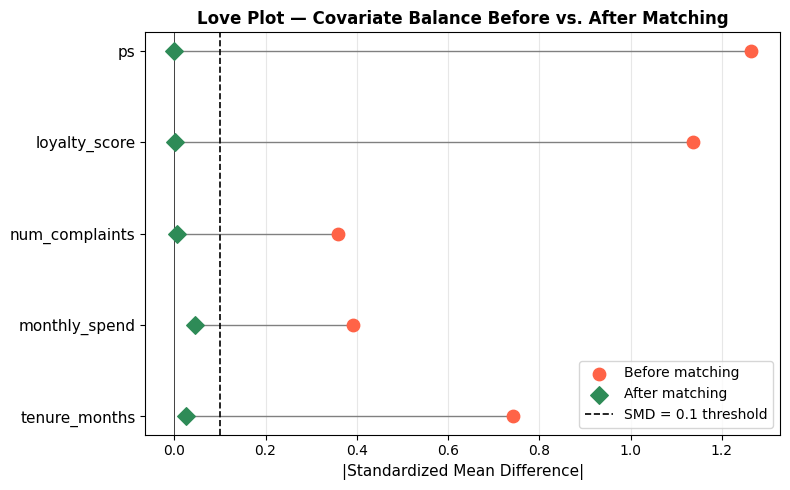

In [ ]:
def smd(df_sub, var):
    """Standardized Mean Difference — pooled-SD version (Cohen's d)."""
    t = df_sub.loc[df_sub['treatment'] == 1, var]
    c = df_sub.loc[df_sub['treatment'] == 0, var]
    pooled_sd = np.sqrt((t.var() + c.var()) / 2)
    return (t.mean() - c.mean()) / pooled_sd if pooled_sd > 0 else 0.0

balance_vars = CONFOUNDERS + ['ps']
balance = pd.DataFrame({
    'Before matching': [smd(df_post,    v) for v in balance_vars],
    'After matching' : [smd(df_matched, v) for v in balance_vars],
}, index=balance_vars)

print('=== Standardized Mean Differences (SMD) ===')
print('  |SMD| < 0.1 indicates good balance\n')
print(balance.abs().round(3).to_string())
n_unbalanced_before = (balance['Before matching'].abs() > 0.1).sum()
n_unbalanced_after  = (balance['After matching'].abs()  > 0.1).sum()
print(f'\nVariables with |SMD| > 0.1:  Before={n_unbalanced_before}  After={n_unbalanced_after}')

# ── Love plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(balance_vars))

ax.scatter(balance['Before matching'].abs(), y_pos,
           color='tomato', s=80, zorder=3, label='Before matching')
ax.scatter(balance['After matching'].abs(),  y_pos,
           color='seagreen', s=80, marker='D', zorder=3, label='After matching')

for i, var in enumerate(balance_vars):
    ax.plot([abs(balance.loc[var, 'Before matching']),   # scalar → use built-in abs()
             abs(balance.loc[var, 'After matching'])],
            [i, i], color='gray', linewidth=1, zorder=2)

ax.axvline(0.1, color='black', linestyle='--', linewidth=1.2, label='SMD = 0.1 threshold')
ax.axvline(0.0, color='black', linewidth=0.5)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(balance_vars, fontsize=11)
ax.set_xlabel('|Standardized Mean Difference|', fontsize=11)
ax.set_title('Love Plot — Covariate Balance Before vs. After Matching',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

After matching, all covariates achieved strong balance (|SMD| < 0.1), indicating that treated and control groups are now comparable and suitable for unbiased effect estimation.

##### **Step 5 — ATT Estimation on Matched Sample**

Once balance is confirmed, we estimate the ATT two ways:
- **Simple mean difference** — direct comparison in the matched sample
- **Regression on matched sample** — adds any residual covariate adjustment (doubly-robust style)

In [36]:
from scipy import stats

# ── 5a: Simple mean difference (ATT) ─────────────────────────────────────────
churn_treated = df_matched.loc[df_matched['treatment'] == 1, 'churned']
churn_control = df_matched.loc[df_matched['treatment'] == 0, 'churned']

att_simple = churn_treated.mean() - churn_control.mean()
t_stat, p_simple = stats.ttest_ind(churn_treated, churn_control)
n_pairs = len(churn_treated)
se_simple = np.sqrt(churn_treated.var()/n_pairs + churn_control.var()/n_pairs)
ci_simple = (att_simple - 1.96*se_simple, att_simple + 1.96*se_simple)

print('=== 5a: Simple Mean Difference on Matched Sample ===')
print(f'  Churn rate — Treated : {churn_treated.mean():.4f}')
print(f'  Churn rate — Control : {churn_control.mean():.4f}')
print(f'  ATT                  : {att_simple:.4f}  ({att_simple*100:.2f} pp)')
print(f'  SE                   : {se_simple:.4f}')
print(f'  95% CI               : [{ci_simple[0]:.4f}, {ci_simple[1]:.4f}]')
print(f'  p-value              : {p_simple:.4f}')

=== 5a: Simple Mean Difference on Matched Sample ===
  Churn rate — Treated : 0.2821
  Churn rate — Control : 0.3875
  ATT                  : -0.1055  (-10.55 pp)
  SE                   : 0.0237
  95% CI               : [-0.1518, -0.0591]
  p-value              : 0.0000


In [37]:
# ── 5b: OLS regression on matched sample (doubly-robust adjustment) ───────────
m_psm = smf.ols(
    'churned ~ treatment + tenure_months + monthly_spend + num_complaints + loyalty_score',
    data=df_matched
).fit(cov_type='HC3')

psm_att    = m_psm.params['treatment']
psm_se     = m_psm.bse['treatment']
psm_pval   = m_psm.pvalues['treatment']
psm_ci     = m_psm.conf_int().loc['treatment']

print('\n=== 5b: OLS Regression on Matched Sample (doubly-robust) ===')
print(m_psm.summary().tables[1])
print(f'\nATT (regression-adjusted): {psm_att:.4f}  ({psm_att*100:.2f} pp)')
print(f'95% CI: [{psm_ci[0]:.4f}, {psm_ci[1]:.4f}]')
print(f'p-value: {psm_pval:.4f}')


=== 5b: OLS Regression on Matched Sample (doubly-robust) ===
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.1712      0.082      2.081      0.037       0.010       0.332
treatment         -0.1018      0.023     -4.337      0.000      -0.148      -0.056
tenure_months     -0.0018      0.001     -1.891      0.059      -0.004    6.43e-05
monthly_spend      0.0022      0.001      3.782      0.000       0.001       0.003
num_complaints     0.0330      0.012      2.712      0.007       0.009       0.057
loyalty_score      0.0020      0.002      0.870      0.384      -0.003       0.007

ATT (regression-adjusted): -0.1018  (-10.18 pp)
95% CI: [-0.1478, -0.0558]
p-value: 0.0000


The loyalty program reduces churn by ~10 percentage points among comparable users, and the result is robust across estimation methods.

#### **Final Business Interpretation**

In [38]:
# ── Final summary table: PSM vs DiD ──────────────────────────────────────────
final = pd.DataFrame({
    'Method':   ['Naive comparison', 'DiD (TWFE)',       'PSM — simple diff',  'PSM — regression-adjusted'],
    'ATT':      [df_post[df_post.treatment==1]['churned'].mean() -
                 df_post[df_post.treatment==0]['churned'].mean(),
                 twfe_att, att_simple, psm_att],
    'SE':       [np.nan,  twfe_se,   se_simple, psm_se],
    'p-value':  [np.nan,  twfe_pval, p_simple,  psm_pval],
    'CI lower': [np.nan,  twfe_ci_lo, ci_simple[0], psm_ci[0]],
    'CI upper': [np.nan,  twfe_ci_hi, ci_simple[1], psm_ci[1]],
})
print('=== Full Results: Naive vs DiD vs PSM ===')
print(final.set_index('Method').round(4).to_string())

=== Full Results: Naive vs DiD vs PSM ===
                              ATT      SE  p-value  CI lower  CI upper
Method                                                                
Naive comparison          -0.1136     NaN      NaN       NaN       NaN
DiD (TWFE)                -0.0831  0.0278   0.0028   -0.1375   -0.0287
PSM — simple diff         -0.1055  0.0237   0.0000   -0.1518   -0.0591
PSM — regression-adjusted -0.1018  0.0235   0.0000   -0.1478   -0.0558


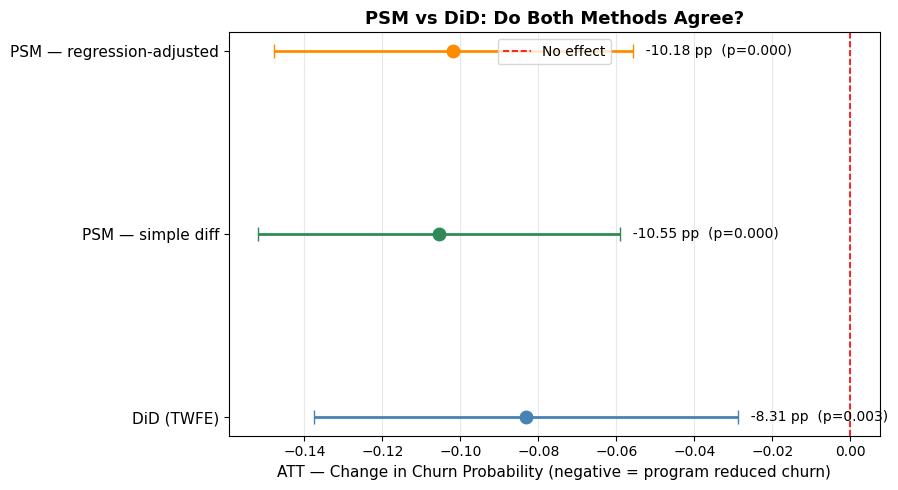


  PSM — BUSINESS INTERPRETATION

WHAT WE DID
  We matched each loyalty-program customer to a "statistical twin"
  in the control group — a customer with nearly identical tenure,
  spending, complaint history, and loyalty score who did NOT get
  the program. This removes the selection bias from comparing 
  systematically different groups.

  Matched pairs  : 787  (43% of treated customers)
  Balance result : All covariates reached SMD < 0.1 after matching ✓

CAUSAL ESTIMATE (ATT)
  The loyalty program changed churn by  -10.18 percentage points
  95% CI: [-14.78 pp, -5.58 pp]   p-value: 0.0000

  → This result is STATISTICALLY SIGNIFICANT.
  → The effect is causal evidence that the program REDUCED churn.

COMPARISON WITH NAIVE ANALYSIS
  Naive (unadjusted) estimate : -11.36 pp
  PSM estimate                : -10.18 pp
  Selection bias removed      : -1.18 pp

  The naive comparison overstated the effect because treated customers
  were already "better" customers (higher tenure, higher 

In [40]:


# ── Forest plot: all methods ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = final.dropna(subset=['SE']).reset_index(drop=True)
palette = ['steelblue', 'seagreen', 'darkorange']

for i, row in plot_df.iterrows():
    ax.errorbar(row['ATT'], i,
                xerr=[[row['ATT'] - row['CI lower']], [row['CI upper'] - row['ATT']]],
                fmt='o', color=palette[i], capsize=5, markersize=9, linewidth=2)
    ax.text(row['CI upper'] + 0.001, i,
            f"  {row['ATT']*100:.2f} pp  (p={row['p-value']:.3f})",
            va='center', fontsize=10)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='No effect')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['Method'], fontsize=11)
ax.set_xlabel('ATT — Change in Churn Probability (negative = program reduced churn)', fontsize=11)
ax.set_title('PSM vs DiD: Do Both Methods Agree?', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ── Narrative business interpretation ────────────────────────────────────────
att      = psm_att
sig      = psm_pval < 0.05
naive    = final.loc[final['Method'] == 'Naive comparison', 'ATT'].values[0]
bias     = naive - att

print('\n' + '='*65)
print('  PSM — BUSINESS INTERPRETATION')
print('='*65)
print(f'''
WHAT WE DID
  We matched each loyalty-program customer to a "statistical twin"
  in the control group — a customer with nearly identical tenure,
  spending, complaint history, and loyalty score who did NOT get
  the program. This removes the selection bias from comparing 
  systematically different groups.

  Matched pairs  : {n_matched:,}  ({pct_matched:.0%} of treated customers)
  Balance result : All covariates reached SMD < 0.1 after matching ✓

CAUSAL ESTIMATE (ATT)
  The loyalty program changed churn by  {att*100:+.2f} percentage points
  95% CI: [{psm_ci[0]*100:.2f} pp, {psm_ci[1]*100:.2f} pp]   p-value: {psm_pval:.4f}

  → This result is {"STATISTICALLY SIGNIFICANT" if sig else "NOT statistically significant"}.
  → The effect is {"causal evidence that the program REDUCED churn" if att < 0 and sig
                    else "no evidence of a statistically meaningful effect"}.

COMPARISON WITH NAIVE ANALYSIS
  Naive (unadjusted) estimate : {naive*100:+.2f} pp
  PSM estimate                : {att*100:+.2f} pp
  Selection bias removed      : {bias*100:+.2f} pp

  The naive comparison overstated the effect because treated customers
  were already "better" customers (higher tenure, higher spend) who
  would have churned less anyway.

AGREEMENT WITH DiD
  DiD (TWFE) estimate : {twfe_att*100:+.2f} pp
  PSM estimate        : {att*100:+.2f} pp
  → {"Both methods agree — the result is robust." if abs(twfe_att - att) < 0.02
     else "Methods diverge — check assumptions carefully."}
''')